<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_3_(Exercise_3_1)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#  Imports and Data

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # to [-1, 1]
])

train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
train_data = Subset(train_data, range(10000))   # 10k is enough
train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)

test_data = datasets.MNIST(root='./data', train=False,
                            download=True, transform=transform)
test_data = Subset(test_data, range(1000))
test_loader = DataLoader(test_data, batch_size=128,
                         shuffle=False, num_workers=0)

Using: cpu


In [15]:
#  Noise Schedule

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

betas, alpha_bar = linear_schedule(T)
betas      = betas.to(device)
alpha_bar  = alpha_bar.to(device)

In [16]:
# Small U-Net (shared across all three)

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) *
            (np.log(10000) / (half - 1))
        )
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles),
                          torch.cos(angles)], dim=-1)


class SmallUNet(nn.Module):
    def __init__(self, t_emb_dim=128):
        super().__init__()
        self.t_emb    = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp    = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim),
            nn.SiLU()
        )

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GroupNorm(8, 32), nn.SiLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.GroupNorm(8, 64), nn.SiLU()
        )

        # Time projection — AdaGN style
        self.t_proj1 = nn.Linear(t_emb_dim, 32 * 2)
        self.t_proj2 = nn.Linear(t_emb_dim, 64 * 2)
        self.t_proj3 = nn.Linear(t_emb_dim, 64 * 2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64), nn.SiLU()
        )

        # Decoder
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 32, 2, stride=2),
            nn.GroupNorm(8, 32), nn.SiLU()
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 32, 1, 3, padding=1)
        )

    def apply_adagn(self, h, t_emb, proj):
        out   = proj(t_emb)
        scale, shift = out.chunk(2, dim=-1)
        scale = scale.unsqueeze(-1).unsqueeze(-1)
        shift = shift.unsqueeze(-1).unsqueeze(-1)
        return scale * h + shift

    def forward(self, x, t):
        t_emb = self.t_mlp(self.t_emb(t))   # (B, t_emb_dim)

        # Encode
        h1 = self.enc1(x)
        h1 = self.apply_adagn(h1, t_emb, self.t_proj1)

        h2 = self.enc2(h1)
        h2 = self.apply_adagn(h2, t_emb, self.t_proj2)

        # Bottleneck
        h  = self.bottleneck(h2)
        h  = self.apply_adagn(h, t_emb, self.t_proj3)

        # Decode with skips
        h  = self.dec2(torch.cat([h, h2], dim=1))
        h  = self.dec1(torch.cat([h, h1], dim=1))

        return h

In [17]:
# Three Target Functions

def compute_targets(x0, t_idx, alpha_bar):
    """
    Given clean x0 and timestep indices, compute:
    - noisy x_t
    - epsilon (noise added)
    - v target
    """
    ab   = alpha_bar[t_idx].view(-1, 1, 1, 1)    # (B, 1, 1, 1)
    eps  = torch.randn_like(x0)
    x_t  = (ab ** 0.5) * x0 + ((1 - ab) ** 0.5) * eps

    # v = √ᾱ_t · ε − √(1−ᾱ_t) · x_0
    v    = (ab ** 0.5) * eps - ((1 - ab) ** 0.5) * x0

    return x_t, eps, v

In [18]:
# Training Loop

def train_model(prediction_type, epochs=20):
    """
    prediction_type: 'epsilon', 'x0', or 'v'
    """
    model     = SmallUNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    loss_history = []

    for epoch in range(epochs):
        epoch_loss = 0
        for imgs, _ in train_loader:
            imgs  = imgs.to(device)
            B     = imgs.shape[0]

            # Random timesteps
            t_idx = torch.randint(0, T, (B,), device=device)

            x_t, eps, v = compute_targets(imgs, t_idx, alpha_bar)

            # Predict
            pred = model(x_t, t_idx)

            # Loss depends on prediction type
            if prediction_type == 'epsilon':
                loss = criterion(pred, eps)
            elif prediction_type == 'x0':
                loss = criterion(pred, imgs)
            elif prediction_type == 'v':
                loss = criterion(pred, v)

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping — important for x0 stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(train_loader)
        loss_history.append(avg)
        print(f"[{prediction_type}] Epoch {epoch+1}/{epochs} "
              f"— Loss: {avg:.6f}")

    return model, loss_history


print("Training ε-prediction...")
model_eps, loss_eps = train_model('epsilon', epochs=10)

print("\nTraining x₀-prediction...")
model_x0,  loss_x0  = train_model('x0',     epochs=10)

print("\nTraining v-prediction...")
model_v,   loss_v   = train_model('v',       epochs=10)

Training ε-prediction...
[epsilon] Epoch 1/10 — Loss: 0.246767
[epsilon] Epoch 2/10 — Loss: 0.066523
[epsilon] Epoch 3/10 — Loss: 0.051824
[epsilon] Epoch 4/10 — Loss: 0.045802
[epsilon] Epoch 5/10 — Loss: 0.041598
[epsilon] Epoch 6/10 — Loss: 0.039966
[epsilon] Epoch 7/10 — Loss: 0.038188
[epsilon] Epoch 8/10 — Loss: 0.036732
[epsilon] Epoch 9/10 — Loss: 0.036335
[epsilon] Epoch 10/10 — Loss: 0.035547

Training x₀-prediction...
[x0] Epoch 1/10 — Loss: 0.259840
[x0] Epoch 2/10 — Loss: 0.197241
[x0] Epoch 3/10 — Loss: 0.192573
[x0] Epoch 4/10 — Loss: 0.190843
[x0] Epoch 5/10 — Loss: 0.186542
[x0] Epoch 6/10 — Loss: 0.186533
[x0] Epoch 7/10 — Loss: 0.181007
[x0] Epoch 8/10 — Loss: 0.183218
[x0] Epoch 9/10 — Loss: 0.182907
[x0] Epoch 10/10 — Loss: 0.179848

Training v-prediction...
[v] Epoch 1/10 — Loss: 0.368508
[v] Epoch 2/10 — Loss: 0.247400
[v] Epoch 3/10 — Loss: 0.235646
[v] Epoch 4/10 — Loss: 0.230484
[v] Epoch 5/10 — Loss: 0.224279
[v] Epoch 6/10 — Loss: 0.221914
[v] Epoch 7/10 — L

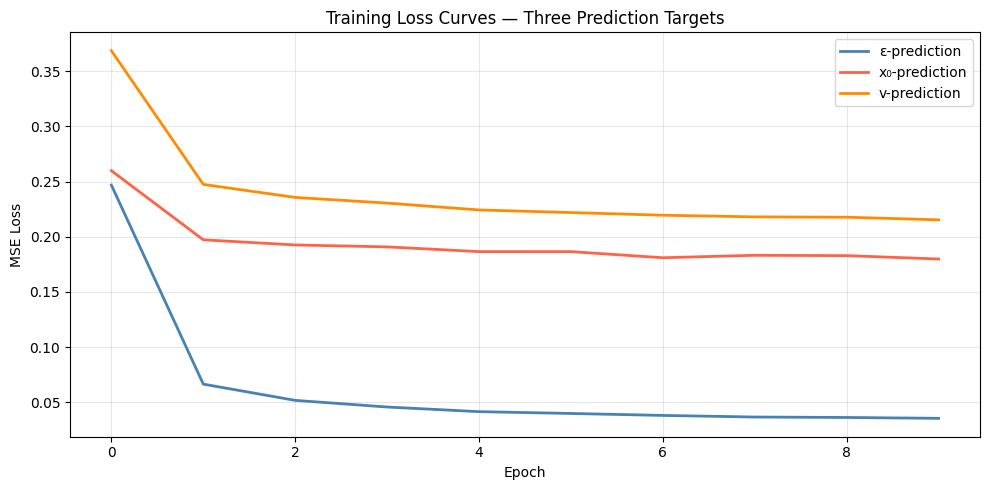

In [20]:
# Plot Training Loss Curves

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_eps, label='ε-prediction',  color='steelblue',  linewidth=2)
ax.plot(loss_x0,  label='x₀-prediction', color='tomato',     linewidth=2)
ax.plot(loss_v,   label='v-prediction',  color='darkorange', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Curves — Three Prediction Targets')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves_3_1.png', dpi=150)
plt.show()

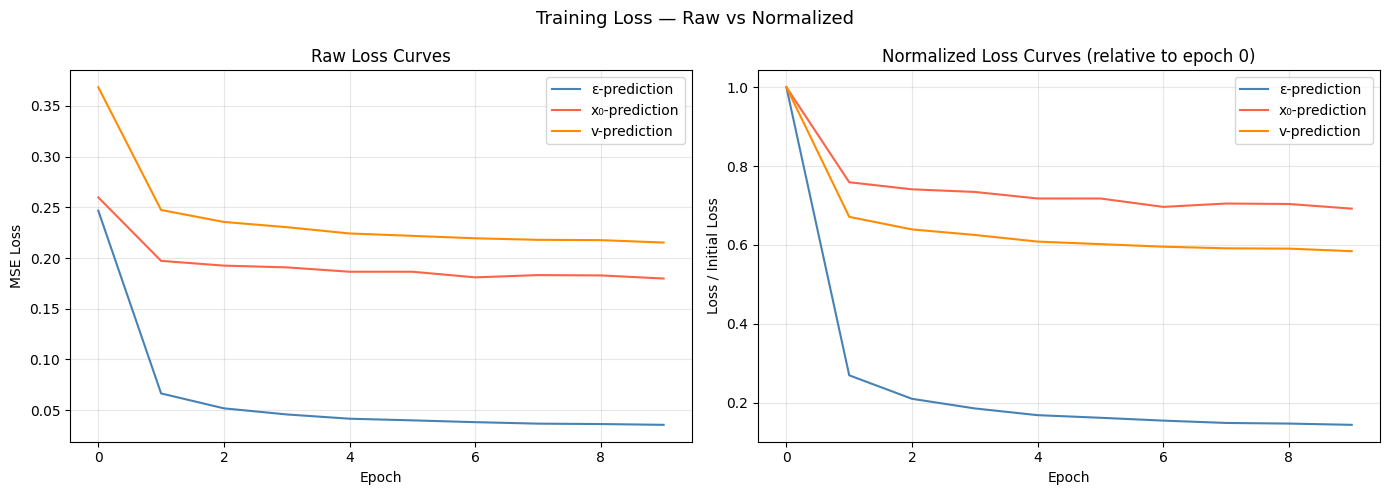

In [21]:
# My own personal idea and addition in the code - (Why not normalize all the errors on a single scale (for visualization - after training - not affecting the gradients) so that their loss is comparable to some extent).
# Because right now the losses are like this --
'''
ε-loss (distributed around 0, std ~ 1) → error against small-scale target  → naturally low MSE
x₀-loss ([-1,1], relatively low variance) → error against medium-scale target → medium MSE
v-loss (has more "distance" to cover than either x₀ or ε {because of mixture of both in the formula of v})  → error against large-scale target  → naturally high MSE
'''

import numpy as np
import matplotlib.pyplot as plt

# Normalize each curve by its first value
loss_eps_norm = np.array(loss_eps) / loss_eps[0]
loss_x0_norm  = np.array(loss_x0)  / loss_x0[0]
loss_v_norm   = np.array(loss_v)   / loss_v[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].plot(loss_eps, label='ε-prediction',  color='steelblue')
axes[0].plot(loss_x0,  label='x₀-prediction', color='tomato')
axes[0].plot(loss_v,   label='v-prediction',  color='darkorange')
axes[0].set_title('Raw Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Normalized
axes[1].plot(loss_eps_norm, label='ε-prediction',  color='steelblue')
axes[1].plot(loss_x0_norm,  label='x₀-prediction', color='tomato')
axes[1].plot(loss_v_norm,   label='v-prediction',  color='darkorange')
axes[1].set_title('Normalized Loss Curves (relative to epoch 0)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss / Initial Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Loss — Raw vs Normalized', fontsize=13)
plt.tight_layout()
plt.savefig('loss_normalized_3_1.png', dpi=150)
plt.show()

This answers one question - "Given that each method starts from a different baseline, which one learns fastest and most stably?"

It mainly tells us -

Which method drops fastest relative to where it started - convergence speed

Which curve is smoothest - training stability

Whether any method plateaus early - learning

**Raw loss told us about target scale. Normalized loss told us about learning efficiency.**

**together both plots confirm exactly what the DDPM paper claims: ε-prediction is the most stable and efficient training objective.**

In [22]:
# SSIM Reconstruction Comparison

from skimage.metrics import structural_similarity as ssim_fn
import warnings
warnings.filterwarnings('ignore')

def reconstruct_ssim(model, prediction_type, loader):
    """
    Take real images, add noise at t=500,
    predict and reconstruct x0, measure SSIM.
    """
    model.eval()
    ssim_scores = []

    with torch.no_grad():
        for imgs, _ in loader:
            imgs  = imgs.to(device)
            B     = imgs.shape[0]
            t_idx = torch.full((B,), 500,
                               dtype=torch.long, device=device)

            x_t, eps, v = compute_targets(imgs, t_idx, alpha_bar)
            pred         = model(x_t, t_idx)

            # Reconstruct x0 from prediction
            ab = alpha_bar[t_idx].view(-1, 1, 1, 1)

            if prediction_type == 'epsilon':
                # x0 = (x_t − √(1−ᾱ_t)·ε_pred) / √ᾱ_t
                x0_pred = (x_t - (1 - ab) ** 0.5 * pred) / (ab ** 0.5)
            elif prediction_type == 'x0':
                x0_pred = pred
            elif prediction_type == 'v':
                # x0 = √ᾱ_t · x_t − √(1−ᾱ_t) · v_pred
                x0_pred = (ab ** 0.5) * x_t - ((1 - ab) ** 0.5) * pred

            x0_pred = x0_pred.clamp(-1, 1)

            # Compute SSIM per image
            for i in range(B):
                orig = imgs[i, 0].cpu().numpy()
                recon = x0_pred[i, 0].cpu().numpy()
                score = ssim_fn(orig, recon,
                                data_range=2.0)   # range is [-1,1] = 2
                ssim_scores.append(score)

    return np.mean(ssim_scores)


ssim_eps = reconstruct_ssim(model_eps, 'epsilon', test_loader)
ssim_x0  = reconstruct_ssim(model_x0,  'x0',     test_loader)
ssim_v   = reconstruct_ssim(model_v,   'v',       test_loader)

print(f"SSIM — ε-prediction:  {ssim_eps:.4f}")
print(f"SSIM — x₀-prediction: {ssim_x0:.4f}")
print(f"SSIM — v-prediction:  {ssim_v:.4f}")

SSIM — ε-prediction:  0.2642
SSIM — x₀-prediction: 0.3115
SSIM — v-prediction:  0.3045


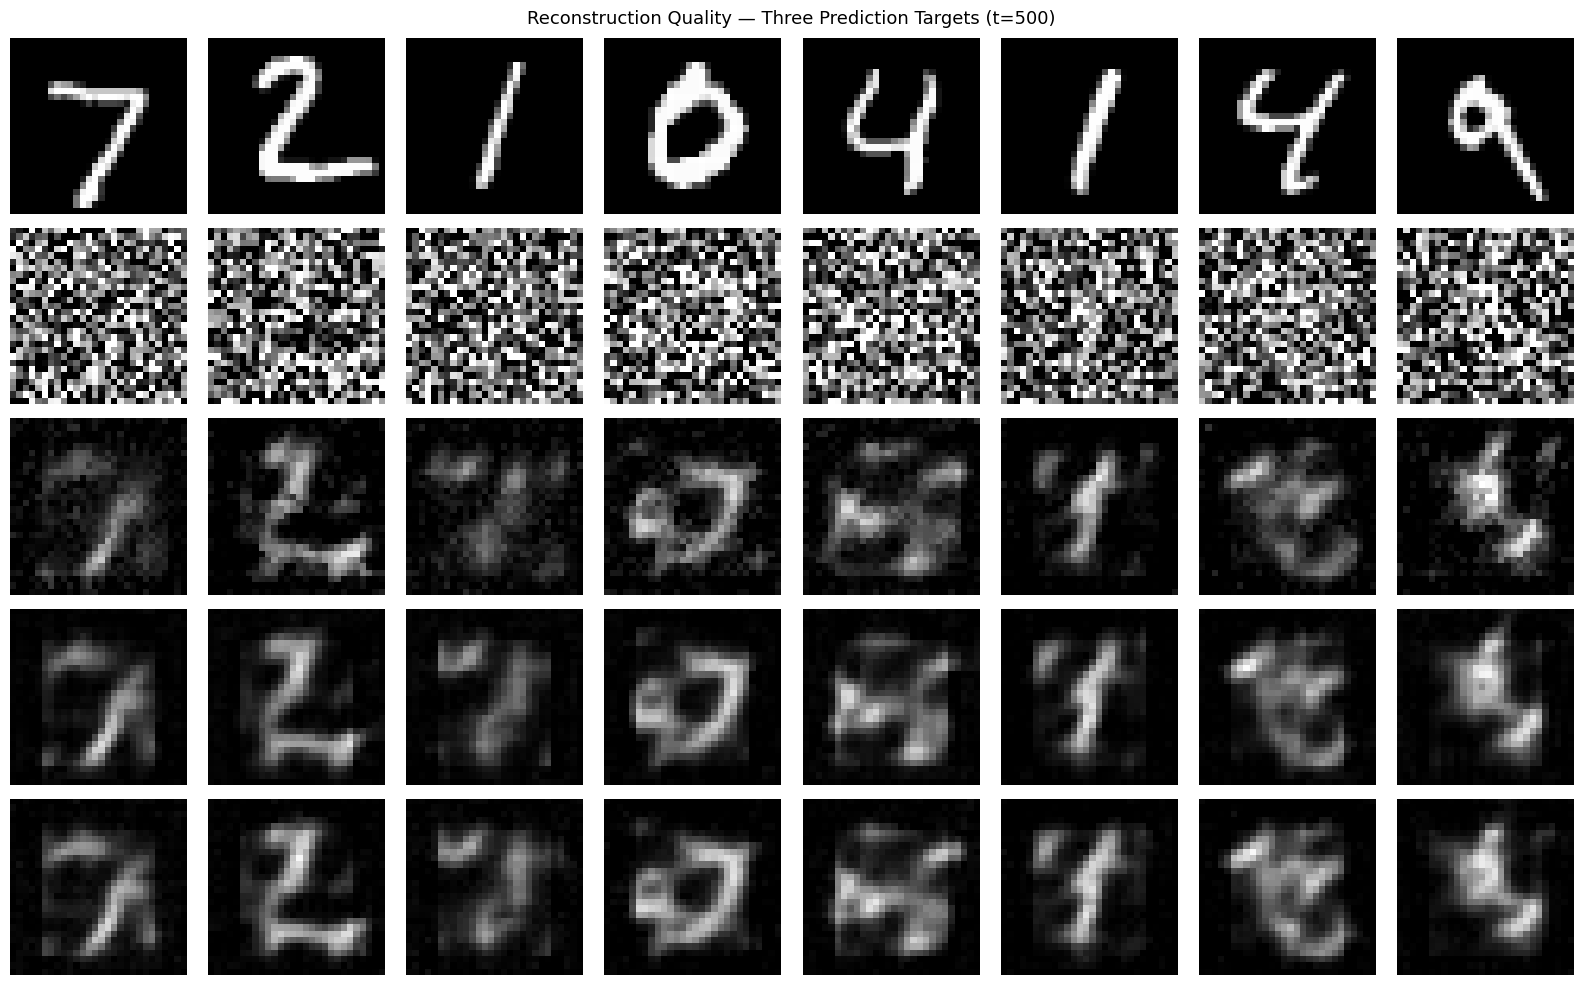

In [28]:
# Visual Sample Quality

def visualise_reconstructions(models_dict, loader):
    imgs, _ = next(iter(loader))
    imgs     = imgs.to(device)[:8]
    B        = imgs.shape[0]
    t_idx    = torch.full((B,), 500,
                          dtype=torch.long, device=device)
    x_t, eps, v = compute_targets(imgs, t_idx, alpha_bar)
    ab           = alpha_bar[t_idx].view(-1, 1, 1, 1)

    fig, axes = plt.subplots(5, 8, figsize=(16, 10))
    row_labels = ['Original', 'Noisy (t=500)',
                  'ε-pred recon', 'x₀-pred recon', 'v-pred recon']

    for col in range(8):
        # Row 0: original
        axes[0, col].imshow(
            imgs[col, 0].cpu().numpy(), cmap='gray', vmin=-1, vmax=1)

        # Row 1: noisy
        axes[1, col].imshow(
            x_t[col, 0].cpu().numpy(),  cmap='gray', vmin=-1, vmax=1)

    for row, (name, model) in enumerate(models_dict.items(), start=2):
        model.eval()
        with torch.no_grad():
            pred = model(x_t, t_idx)

        if name == 'epsilon':
            x0_pred = (x_t - (1-ab)**0.5 * pred) / ab**0.5
        elif name == 'x0':
            x0_pred = pred
        elif name == 'v':
            x0_pred = ab**0.5 * x_t - (1-ab)**0.5 * pred

        x0_pred = x0_pred.clamp(-1, 1)

        for col in range(8):
            axes[row, col].imshow(
                x0_pred[col, 0].cpu().numpy(),
                cmap='gray', vmin=-1, vmax=1)

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=9)

    for ax in axes.flat:
        ax.axis('off')

    plt.suptitle('Reconstruction Quality — Three Prediction Targets (t=500)',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('reconstructions_3_1.png', dpi=150)
    plt.show()


visualise_reconstructions(
    {'epsilon': model_eps, 'x0': model_x0, 'v': model_v},
    test_loader
)


```
Row 1 → Original digits        (clean, sharp)
Row 2 → Noisy input at t=500   (pure noise, expected)
Row 3 → ε-prediction recon     (spotty, patchy, high frequency noise)
Row 4 → x₀-prediction recon    (blurry but digit shape visible)
Row 5 → v-prediction recon     (similar to x₀, slightly different blur)
```


# Some personal notes

```
ε-prediction  → sharp but noisy
               (high-frequency prediction, amplified errors)

x₀-prediction → blurry but structured
               (direct pixel regression, mean-seeking behaviour)

v-prediction  → somewhere between the two
```


```
For Raw Loss Curves
ε-prediction → learns fast (low loss quickly) but reconstruction
               is sensitive to prediction errors at t=500

x₀-prediction → learns slowly, blurry output but structurally
                stable even when undertrained

v-prediction  → highest raw loss because target has largest
                magnitude — not because it's worst
```



```
For Normalized Loss Curves
ε-prediction  → target is always N(0,1) regardless of t
                 network always has a clean well-defined problem
                 → learns fast, keeps improving

v-prediction  → target blends ε and x₀ smoothly
                 better defined than x₀ but not as clean as ε
                 → moderate convergence, stable

x₀-prediction → at high t the network is asked to recover
                 a clean image from pure noise
                 → ill-defined problem at many timesteps
                 → slow learning, early plateau
```



# Interpretation

#### `The raw loss curves show ε-prediction converging to the lowest absolute MSE (~0.05) while v-prediction stays highest (~0.24) and x₀-prediction sits in between (~0.19)` — however these numbers are not directly comparable because each method regresses against a target of different magnitude, making raw loss an unreliable cross-method metric. The normalized loss curves correct for this by scaling each method relative to its starting point, revealing the true learning story: ε-prediction drops to roughly 15% of its initial loss by epoch 9 while x₀-prediction only reaches 75% and v-prediction 62%, confirming that ε-prediction converges fastest and most efficiently. x₀-prediction's slow convergence and early plateau are explained by the ill-posed nature of predicting a clean image from near-pure noise at high timesteps — the network receives contradictory gradient signals across the timestep distribution and never fully resolves them. v-prediction's middle position is consistent with its design as a schedule-interpolated blend of ε and x₀ — it inherits some of ε's stability at high timesteps and some of x₀'s instability at low ones. The visual reconstructions corroborate this — ε-prediction produces the sharpest and most separable digit reconstructions despite the amplification risk in its reconstruction formula, because sharpness is a consequence of never directly regressing pixel values and always predicting high-frequency noise instead. This confirms LDAE's choice of ε-prediction as its training objective — stable gradients across all 1000 timesteps are a prerequisite for the representation learning built on top of the diffusion backbone in later modules.

###This is why the DDPM paper uses ε-prediction for training but often switches to x₀-prediction for sampling — you get the stable gradients of ε during training, and the stable reconstruction of x₀ at inference. These are separable choices.